# Segunda fase

In [1]:
# Importing classes of the project

# Reload classes in memory every time this code block is executed
%load_ext autoreload
%autoreload 2

import os
from collections import Counter
import numpy as np
import pandas as pd
import torch
import seaborn as sns
from imblearn.over_sampling import SMOTE
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.utils import compute_class_weight
from sklearn.metrics import confusion_matrix

from data_analysis.analizer import DataAnalizer

# model evaluator
from model_building.ModelEvaluator import ModelEvaluator
# KNN
from model_building.KNN import KNN
# Supervised Learning
from model_building.DecisionTree import DecisionTree
from model_building.LinearModels import LinearModels

# Boosting and Bagging
from model_building.RandomForest import RandomForest
from model_building.AdaBoost import AdaBoost
# Deep Learning
from model_building.BaseNeuralNetwork import BaseNeuralNetwork
from model_building.NeuralNetworkTrainer import NeuralNetworkTrainer
# Clustering
from model_building.HDBSCANMixed import HDBSCANMixed
from model_building.KPrototypes import KPrototypesModel

In [2]:
# ==========================================
#  Setup do diretório de output dos modelos
# ==========================================
model_output_dir = "../out/models/"
os.makedirs(model_output_dir, exist_ok=True)


# ==================
#  Setup do dataset
# ==================

df = pd.read_csv("../out/dataset.csv")

# a grande maioria das entradas têm valores nulos em "congestion_surcharge"
del df["congestion_surcharge"]

# dados continuos (não é possivel normalizar estes dados)
del df["pickup_time_in_seconds"]
del df["dropoff_time_in_seconds"]

# Remove all rows with any missing values (NaN)
df= df.dropna()

# =============================================
# 1. REGRESSION DATASET (continuous target)
# =============================================

# Separate features and target
X_reg = df.drop(columns=['fare_amount'])
y_reg = df['fare_amount']

# Scale only the features (not target)
scaler = StandardScaler()
X_reg_scaled = scaler.fit_transform(X_reg)

# Create scaled DataFrame for regression
df_regression = pd.DataFrame(X_reg_scaled, columns=X_reg.columns)
df_regression['fare_amount'] = y_reg.values  # Add unscaled target

analizer_reg = DataAnalizer(df_regression, "fare_amount", test_size=0.02)


# =============================================
# 2. CLASSIFICATION DATASET (categorical target)
# =============================================

# Create fare classes
bins = [-np.inf, 10, 30, 60, np.inf]
labels = [1, 2, 3, 4]

# Create classification target
df_classification = df.copy()
df_classification['fare_class'] = pd.cut(
    df['fare_amount'],
    bins=bins,
    labels=labels
)

# Separate features and target
X_clf = df_classification.drop(columns=['fare_amount', 'fare_class'])
y_clf = df_classification['fare_class']

# Scale features using SAME scaler (important for consistency)
X_clf_scaled = scaler.transform(X_clf)  # Use existing scaler

# Create scaled DataFrame for classification
df_classification_scaled = pd.DataFrame(X_clf_scaled, columns=X_clf.columns)
df_classification_scaled['fare_class'] = y_clf.values  # Add target

analizer_clf = DataAnalizer(df_classification_scaled, "fare_class", test_size=0.2)

# =============================================
# Verification
# =============================================
print("Regression dataset:")
print(df_regression.head())

print("\nClassification dataset:")
print(df_classification_scaled.head())

print(df_classification['fare_class'].value_counts(normalize=True))


Data divided successfully.
Data divided successfully.
Regression dataset:
   trip_distance  tip_amount  tolls_amount     extra  passenger_count  \
0      -0.666634   -0.760919     -0.229742 -0.463238        -0.470065   
1      -0.404075    0.619532     -0.229742 -0.463238        -0.470065   
2      -0.455557   -0.174228     -0.229742 -0.463238        -0.470065   
3      -0.149237   -0.760919     -0.229742 -0.463238        -0.470065   
4       1.665513    0.964644     -0.229742 -0.463238        -0.470065   

   pickup_hour  pickup_day_of_week  pickup_day_of_month  pickup_month  \
0    -2.316139           -1.018927            -1.674574     -1.532716   
1    -2.316139           -1.018927            -1.674574     -1.532716   
2    -2.316139           -1.018927            -1.674574     -1.532716   
3    -2.316139           -1.018927            -1.674574     -1.532716   
4    -2.316139           -1.018927            -1.674574     -1.532716   

   dropoff_hour  dropoff_day_of_week  dropoff_da

# KNN

O KNN (K-Nearest Neighbors, ou K-Vizinhos Mais Próximos) é um algoritmo de aprendizado de máquina supervisionado usado para classificação e regressão. Ele se baseia no princípio de que objetos semelhantes estão próximos no espaço de características.

**Funcionamento:**


Calcula a distância (ex.: Euclidiana, Manhattan) entre o novo dado e todos os pontos no conjunto de treinamento.

Seleciona os K vizinhos mais próximos.

Classifica (moda das classes dos vizinhos) ou prediz (média dos valores dos vizinhos).



In [3]:
k_values_knn_reg = [1, 3, 5, 10, 15]
best_cv_rmse_knn_reg = float('inf')
best_k_knn_reg = None
all_cv_results_knn_reg = {} # To store CV results for each k

for k_val in k_values_knn_reg:
    print(f"\nEvaluating KNN Regressor with k = {k_val} using Cross-Validation on training data...")

    # 1. Create the KNN model for regression
    current_knn_model = KNN(k=k_val, task='regression', verbose=False)

    # 2. Instantiate ModelEvaluator for cross-validation evaluation
    # The model (current_knn_model) will be trained inside the folds by ModelEvaluator
    evaluator_cv = ModelEvaluator(
        model=current_knn_model, # ModelEvaluator will clone and train this model in each fold
        task_type="regression",
        metrics=["rmse", "mae", "r2"],
        cv_method='kfold',
        cv_folds=5,
    )

    try:
        # 3. Evaluate using TRAINING data with Cross-Validation
        # cv_strategy=True ensures ModelEvaluator will use 'kfold' with 5 folds
        # on the provided data (analizer_reg.data_train, analizer_reg.labels_train)
        cv_results = evaluator_cv.evaluate(
            X=analizer_reg.data_train,
            y=analizer_reg.labels_train,
            cv_strategy=True
        )
        all_cv_results_knn_reg[k_val] = cv_results

        print(f"Cross-Validation (CV) Results for k={k_val}:")
        for metric, value in cv_results.items():
            if isinstance(value, (int, float, np.number)): # np.number to cover numpy numeric types
                print(f"  {metric}: {value:.4f}")
            # else: # For 'predictions' or 'probabilities' if return_predictions=True
            #     print(f"  {metric}: {value}")

        # 4. Logic to select the best k based on the average CV RMSE
        current_cv_rmse_mean = cv_results.get('rmse_mean')
        if current_cv_rmse_mean is not None and current_cv_rmse_mean < best_cv_rmse_knn_reg:
            best_cv_rmse_knn_reg = current_cv_rmse_mean
            best_k_knn_reg = k_val
            print(f"  -> New best k found by CV: {best_k_knn_reg} (rmse_mean={best_cv_rmse_knn_reg:.4f})")

    except Exception as e:
        print(f"An error occurred during CV evaluation for k={k_val}: {e}")

# --- Train and Evaluate the Best Regression Model on the Test Set and Save ---
if best_k_knn_reg is not None:
    print("-" * 30)
    print(f"Best k found after Cross-Validation: {best_k_knn_reg} (CV rmse_mean: {best_cv_rmse_knn_reg:.4f})")

    # 1. Train the final model with the best k on ALL TRAINING data
    print(f"Retraining the KNN model with k={best_k_knn_reg} on the complete training set...")
    final_best_knn_model_reg = KNN(k=best_k_knn_reg, task='regression', verbose=False)


    final_best_knn_model_reg.fit(analizer_reg.data_train, analizer_reg.labels_train)

    # 2. Evaluate the final model on the TEST set (without CV)
    print("Evaluating the final model on the test set...")
    evaluator_test = ModelEvaluator(
        model=final_best_knn_model_reg, # Already trained model
        task_type="regression",
        metrics=["rmse", "mae", "r2"],
        cv_method=None # Ensure no CV here
    )
    # By default, cv_strategy=None and cv_method=None in evaluator_test
    # will perform a direct evaluation without CV.
    test_results_knn_reg = evaluator_test.evaluate(
        X=analizer_reg.data_test,
        y=analizer_reg.labels_test
    )

    print("Evaluation Results on the Test Set:")
    for metric, value in test_results_knn_reg.items():
        if isinstance(value, (int, float, np.number)):
            print(f"  {metric}: {value:.4f}")

    # 3. Save the best REGRESSION model
    test_rmse = test_results_knn_reg.get('rmse', float('nan')) # Get the test RMSE for the filename
    model_filename = f"knnRegressor_best_k{best_k_knn_reg}_cvRmse{best_cv_rmse_knn_reg:.2f}_testRmse{test_rmse:.2f}.pkl"
    model_full_path = model_output_dir / model_filename

    print(f"Saving the best KNN regression model to: {model_full_path.resolve()}")
    final_best_knn_model_reg.serialize(model_output_dir+"KNN-Regressor.pkl")
    print(f"Best KNN regression model saved successfully!")
    print("-" * 30)
else:
    print("-" * 30)
    print("No KNN regression model was successfully evaluated and selected after Cross-Validation.")
    print("-" * 30)


Evaluating KNN Regressor with k = 1 using Cross-Validation on training data...
An error occurred during CV evaluation for k=1: ModelEvaluator.evaluate() got an unexpected keyword argument 'cv_strategy'

Evaluating KNN Regressor with k = 3 using Cross-Validation on training data...
An error occurred during CV evaluation for k=3: ModelEvaluator.evaluate() got an unexpected keyword argument 'cv_strategy'

Evaluating KNN Regressor with k = 5 using Cross-Validation on training data...
An error occurred during CV evaluation for k=5: ModelEvaluator.evaluate() got an unexpected keyword argument 'cv_strategy'

Evaluating KNN Regressor with k = 10 using Cross-Validation on training data...
An error occurred during CV evaluation for k=10: ModelEvaluator.evaluate() got an unexpected keyword argument 'cv_strategy'

Evaluating KNN Regressor with k = 15 using Cross-Validation on training data...
An error occurred during CV evaluation for k=15: ModelEvaluator.evaluate() got an unexpected keyword argu

In [4]:
k_values_knn_clf = [1, 3, 5, 10, 15]
best_cv_accuracy_knn_clf = -float('inf')
best_k_knn_clf = None
all_cv_results_knn_clf = {} # To store CV results for each k

for k_val in k_values_knn_clf:
    print(f"\nEvaluating KNN Classifier with k = {k_val} using Cross-Validation on training data...")

    current_knn_model = KNN(k=k_val, task='classification', verbose=False)

    # 2. Instantiate ModelEvaluator for cross-validation evaluation
    evaluator_cv = ModelEvaluator(
        model=current_knn_model,
        task_type="classification",
        metrics=["accuracy", "precision_macro", "recall_macro", "f1_macro"], # Classification metrics
        cv_method='kfold',
        cv_folds=5,
    )

    try:
        # 3. Evaluate using TRAINING data with Cross-Validation
        cv_results = evaluator_cv.evaluate(
            X=analizer_clf.data,
            y=analizer_clf.labels_train,
            cv_strategy=True
        )
        all_cv_results_knn_clf[k_val] = cv_results

        print(f"Cross-Validation (CV) Results for k={k_val}:")
        for metric, value in cv_results.items():
            if isinstance(value, (int, float, np.number)):
                print(f"  {metric}: {value:.4f}")
            # else: # For 'confusion_matrix' or other non-scalar results if returned by CV part
            #     print(f"  {metric}: {value}")

        # 4. Logic to select the best k based on the average CV Accuracy
        current_cv_accuracy_mean = cv_results.get('accuracy_mean')
        if current_cv_accuracy_mean is not None and current_cv_accuracy_mean > best_cv_accuracy_knn_clf:
            best_cv_accuracy_knn_clf = current_cv_accuracy_mean
            best_k_knn_clf = k_val
            print(f"  -> New best k found by CV: {best_k_knn_clf} (accuracy_mean={best_cv_accuracy_knn_clf:.4f})")

    except Exception as e:
        print(f"An error occurred during CV evaluation for k={k_val}: {e}")

# --- Train and Evaluate the Best Classification Model on the Test Set and Save ---
if best_k_knn_clf is not None:
    print("-" * 30)
    print(f"Best k found after Cross-Validation: {best_k_knn_clf} (CV accuracy_mean: {best_cv_accuracy_knn_clf:.4f})")

    # 1. Train the final model with the best k on ALL TRAINING data
    print(f"Retraining the KNN model with k={best_k_knn_clf} on the complete training set...")
    final_best_knn_model_clf = KNN(k=best_k_knn_clf, task='classification', verbose=False)
    final_best_knn_model_clf.fit(analizer_clf.data_train, analizer_clf.labels_train)

    # 2. Evaluate the final model on the TEST set (without CV)
    print("Evaluating the final model on the test set...")
    evaluator_test = ModelEvaluator(
        model=final_best_knn_model_clf, # Already trained model
        task_type="classification",
        metrics=["accuracy", "precision_macro", "recall_macro", "f1_macro", "confusion_matrix"], # Include CM for test
        cv_method=None
    )
    test_results_knn_clf = evaluator_test.evaluate(
        X=analizer_clf.data_test,
        y=analizer_clf.labels_test
    )

    print("Evaluation Results on the Test Set:")
    for metric, value in test_results_knn_clf.items():
        if isinstance(value, (int, float, np.number)):
            print(f"  {metric}: {value:.4f}")
        elif metric == "confusion_matrix": # Specific handling for confusion matrix if you want to print it nicely
             print(f"  {metric}:")
             for row in value:
                 print(f"    {row}")

    # 3. Save the best CLASSIFICATION model
    test_accuracy = test_results_knn_clf.get('accuracy', 0.0)
    model_filename = f"knnClassifier_best_k{best_k_knn_clf}_cvAcc{best_cv_accuracy_knn_clf:.2f}_testAcc{test_accuracy:.2f}.pkl"
    # Ensure model_output_dir is a Path object for this to work seamlessly
    model_full_path = model_output_dir / model_filename

    print(f"Saving the best KNN classification model to: {model_full_path.resolve()}")
    # Use the generated model_full_path for saving
    final_best_knn_model_clf.serialize(model_output_dir+"KNN-Classifier.pkl")
    print(f"Best KNN classification model saved successfully!")
    print("-" * 30)
else:
    print("-" * 30)
    print("No KNN classification model was successfully evaluated and selected after Cross-Validation.")
    print("-" * 30)


Evaluating KNN Classifier with k = 1 using Cross-Validation on training data...


ValueError: Invalid task type: classification.  Must be one of 'binary', 'multiclass', or 'regression'.

# Árvore de decisão

A Árvore de Decisão é um algoritmo de aprendizado de máquina supervisionado usado para classificação e regressão. Ele divide os dados em subconjuntos com base em regras de decisão hierárquicas, formando uma estrutura semelhante a uma árvore.

**Funcionamento:**

Seleciona o melhor atributo para dividir os dados (usando critérios como Gini, Entropia ou Erro quadrático).

Divide o dataset recursivamente, criando nós de decisão até atingir uma condição de parada (ex.: profundidade máxima ou número mínimo de amostras por folha).

Classifica ou prediz com base na folha (nó final) em que o dado cai.

In [3]:
# Classification with Decision Tree
best_f1_macro = -float('inf') # Initialize with a very low value to find the maximum
best_model_clf = None
best_depth_clf = None
all_clf_results = {} # Optional: to store all results if needed

print("--- Classification with Decision Tree ---")

for depth in [None, 2, 5, 10, 20]:
    print(f"\nTraining Decision Tree Classification for max_depth = {depth}")
    dt_clf = DecisionTree(
        problem_type='classification',
        max_depth=depth,
        class_weight='balanced',
        random_state=42 # Added for reproducibility if the tree has random elements
    )

    # evaluate the model
    evaluator = ModelEvaluator(
        model=dt_clf,
        task_type="multiclass",
        metrics=["accuracy", "precision_macro", "recall_macro", "f1_macro", "log_loss"],
        cv_method='stratifiedkfold',
        cv_folds=5,
        random_state=42 # Added for reproducibility in CV
    )

    print(f"max_depth={depth}")
    try:
        results_clf = evaluator.evaluate(analizer_clf.data_train, analizer_clf.labels_train)
        all_clf_results[depth] = results_clf # Store the results

        print("CV Results:")
        for metric, value in results_clf.items():
             # Check if it's a numeric value to format
            if isinstance(value, (int, float)):
                 print(f"{metric}: {value:.4f}")
            else:
                 print(f"{metric}: {value}")


        # --- Logic to select the best model ---
        # We use the mean of the f1_macro from cross-validation for comparison
        current_f1_macro_mean = results_clf.get('f1_macro_mean') # Assumes ModelEvaluator returns metric_mean

        if current_f1_macro_mean is not None and current_f1_macro_mean > best_f1_macro:
            best_f1_macro = current_f1_macro_mean
            best_model_clf = dt_clf # Store the instance of the model trained in the last fold or the rule of the ModelEvaluator class
            best_depth_clf = depth
            print(f"-> New best model found with max_depth={depth} (f1_macro_mean={best_f1_macro:.4f})")

    except Exception as e:
        print(f"An error occurred during evaluation for max_depth={depth}: {e}")

if best_model_clf is not None:
    print("-" * 30)
    print("Saving best model...")
    best_model_clf.serialize(model_output_dir+"decisionTreeClassfier.pkl")
    print("-" * 30)

--- Classificação com Decision Tree ---

Training Decision Tree Classification for max_depth = None
max_depth=None
Resultados CV:
accuracy_mean: 0.8880
precision_macro_mean: 0.8625
recall_macro_mean: 0.8503
f1_macro_mean: 0.8561
log_loss_mean: 4.0379
accuracy_std: 0.0025
precision_macro_std: 0.0101
recall_macro_std: 0.0090
f1_macro_std: 0.0085
log_loss_std: 0.0889
-> Novo melhor modelo encontrado com max_depth=None (f1_macro_mean=0.8561)

Training Decision Tree Classification for max_depth = 2
max_depth=2
Resultados CV:
accuracy_mean: 0.6277
precision_macro_mean: 0.4783
recall_macro_mean: 0.6669
f1_macro_mean: 0.5545
log_loss_mean: 0.7730
accuracy_std: 0.0003
precision_macro_std: 0.0078
recall_macro_std: 0.0076
f1_macro_std: 0.0068
log_loss_std: 0.0014

Training Decision Tree Classification for max_depth = 5
max_depth=5
Resultados CV:
accuracy_mean: 0.8598
precision_macro_mean: 0.7698
recall_macro_mean: 0.8868
f1_macro_mean: 0.8170
log_loss_mean: 0.3490
accuracy_std: 0.0038
precision_m

In [4]:
best_rmse = float('inf') # Initialize with a very high value to find the minimum
best_model_reg = None
best_depth_reg = None
all_reg_results = {} # Optional: to store all results if needed

print("\n" + "=" * 40) # Separator
print("--- Regression with Decision Tree ---")

for depth in [None, 2, 5, 10, 20]:
    print(f"\nTraining Decision Tree Regression for max_depth = {depth}")
    dt_reg = DecisionTree(problem_type='regression', max_depth=depth, random_state=42)

    # Evaluate the model using ModelEvaluator for regression with multiple metrics
    evaluator_reg = ModelEvaluator(
        model=dt_reg,
        task_type="regression",
        metrics=['rmse', 'mse', 'mae', 'r2'],  # Evaluate using RMSE, MSE, MAE, and R-squared
        cv_method='kfold',
        cv_folds=5,
        random_state=42
    )

    print(f"max_depth={depth}")
    try:
        results_reg = evaluator_reg.evaluate(analizer_reg.data_train, analizer_reg.labels_train)
        all_reg_results[depth] = results_reg # Store the results

        print("CV Results:")
        # Extract and print mean/std for key metrics for the current depth
        current_rmse_mean = results_reg.get('rmse_mean')
        current_mse_mean = results_reg.get('mse_mean')
        current_mae_mean = results_reg.get('mae_mean')
        current_r2_mean = results_reg.get('r2_mean')

        if current_rmse_mean is not None: print(f"rmse_mean: {current_rmse_mean:.4f}")
        if results_reg.get('rmse_std') is not None: print(f"rmse_std: {results_reg['rmse_std']:.4f}")
        if current_mse_mean is not None: print(f"mse_mean: {current_mse_mean:.4f}")
        if results_reg.get('mse_std') is not None: print(f"mse_std: {results_reg['mse_std']:.4f}")
        if current_mae_mean is not None: print(f"mae_mean: {current_mae_mean:.4f}")
        if results_reg.get('mae_std') is not None: print(f"mae_std: {results_reg['mae_std']:.4f}")
        if current_r2_mean is not None: print(f"r2_mean: {current_r2_mean:.4f}")
        if results_reg.get('r2_std') is not None: print(f"r2_std: {results_reg['r2_std']:.4f}")


        # --- Logic to select the best REGRESSION model ---
        # We use the mean of the cross-validation rmse for comparison (lower is better)
        # current_rmse_mean is already extracted above

        if current_rmse_mean is not None and current_rmse_mean < best_rmse:
            best_rmse = current_rmse_mean
            best_model_reg = dt_reg # Store the instance of the model configured for this depth
            best_depth_reg = depth
            print(f"-> New best REGRESSION model found with max_depth={depth} (rmse_mean={best_rmse:.4f})")

    except Exception as e:
        print(f"An error occurred during regression evaluation for max_depth={depth}: {e}")

# --- Save the best REGRESSION model ---
if best_model_reg is not None:
    print("-" * 30)
    print("Saving best regression model...")
     # Similar note as classification: re-train on full data if needed before saving
    best_model_reg.serialize(model_output_dir+"decisionTreeRegressor.pkl")
    print(f"Best regression model (max_depth={best_depth_reg}, rmse_mean={best_rmse:.4f}) saved to {model_output_dir}decisionTreeRegressor.pkl")
    print("-" * 30)
else:
     print("-" * 30)
     print("No regression model was successfully evaluated.")
     print("-" * 30)


--- Regressão com Decision Tree ---

Training Decision Tree Regression for max_depth = None
max_depth=None
Resultados CV:
rmse_mean: 5.4510
rmse_std: 1.6482
mse_mean: 32.4301
mse_std: 21.6619
mae_mean: 1.6929
mae_std: 0.0452
r2_mean: 0.8064
r2_std: 0.0861
-> Novo melhor modelo REGRESSÃO encontrado com max_depth=None (rmse_mean=5.4510)

Training Decision Tree Regression for max_depth = 2
max_depth=2
Resultados CV:
rmse_mean: 7.2571
rmse_std: 1.5701
mse_mean: 55.1300
mse_std: 26.4347
mae_mean: 3.4721
mae_std: 0.4183
r2_mean: 0.6623
r2_std: 0.0894

Training Decision Tree Regression for max_depth = 5
max_depth=5
Resultados CV:
rmse_mean: 6.7504
rmse_std: 2.0708
mse_mean: 49.8566
mse_std: 26.4153
mae_mean: 2.0266
mae_std: 0.0646
r2_mean: 0.6866
r2_std: 0.1582

Training Decision Tree Regression for max_depth = 10
max_depth=10
Resultados CV:
rmse_mean: 4.7395
rmse_std: 1.8454
mse_mean: 25.8687
mse_std: 22.5014
mae_mean: 1.5451
mae_std: 0.0345
r2_mean: 0.8505
r2_std: 0.0947
-> Novo melhor mod

# Linear Models

Nesta secção trabalhamos com modelos lineares como Regressão linear e suas variantes para fazer regressão no nosso conjunto de dados e regressão logística para fazer classificação.

In [6]:
best_r2_linear = -float('inf')
best_linear_models_instance = None
best_params_linear_reg = None
all_linear_reg_results = {}

numerical_features = [
    'trip_distance', 'tip_amount', 'tolls_amount', 'extra', 'passenger_count',
    'pickup_hour', 'pickup_day_of_week', 'pickup_day_of_month', 'pickup_month',
    'dropoff_hour', 'dropoff_day_of_week', 'dropoff_day_of_month', 'dropoff_month',
    'mta_tax'
]

categorical_features = [
    'vendorid', 'ratecodeid', 'pulocationid', 'dolocationid', 'payment_type'
]

linear_regression_models = ['linear', 'ridge', 'lasso', 'elasticnet']

for model_name in linear_regression_models:
    print(f"\n--- Training {model_name.upper()} Regression with GridSearchCV ---")

    linear_reg_model = LinearModels(
        problem_type='regression',
        model_name=model_name,
        grid_search=True,
        verbose=1,
        scoring='r2',
        random_state=42
    )

    current_r2_mean_for_comparison = -float('inf')
    current_best_params_for_comparison = {}

    try:
        linear_reg_model.fit(analizer_reg.data_train, analizer_reg.labels_train)

        if linear_reg_model.best_model is not None and linear_reg_model.cv_results is not None:
            results_cv_reg = linear_reg_model.cv_results

            if 'mean_test_score' in results_cv_reg and len(results_cv_reg['mean_test_score']) > 0:
                best_index_reg = np.argmax(results_cv_reg['mean_test_score'])
                current_r2_mean_for_comparison = results_cv_reg['mean_test_score'][best_index_reg]
                current_best_params_for_comparison = results_cv_reg['params'][best_index_reg]

                all_linear_reg_results[model_name] = {
                    'best_r2_mean_cv': current_r2_mean_for_comparison,
                    'best_params': current_best_params_for_comparison,
                    'all_cv_results': results_cv_reg
                }

                print(f"\nCV Results for {model_name.upper()} (Best Combination):")
                print(f"R^2_mean: {current_r2_mean_for_comparison:.4f}")
                print(f"Best Parameters: {current_best_params_for_comparison}")

                evaluation_results = linear_reg_model.evaluate(analizer_reg.data_test, analizer_reg.labels_test)
                print(f"Test MSE: {evaluation_results.get('mean_squared_error', np.nan):.4f}")
                print(f"Test R^2: {evaluation_results.get('r2_score', np.nan):.4f}")

            else:
                print(f"WARNING: 'mean_test_score' not available or empty in CV results for {model_name.upper()}.")
                evaluation_results = linear_reg_model.evaluate(analizer_reg.data_test, analizer_reg.labels_test)
                current_r2_mean_for_comparison = evaluation_results.get('r2_score', -float('inf'))
                current_best_params_for_comparison = {}
                print(f"Test R^2 (fallback): {current_r2_mean_for_comparison:.4f}")

                all_linear_reg_results[model_name] = {
                    'best_r2_mean_test_fallback': current_r2_mean_for_comparison,
                    'best_params': current_best_params_for_comparison,
                    'all_cv_results': {}
                }
        else:
            print(f"WARNING: Model {model_name.upper()} was not trained successfully (best_model or cv_results are None after fit).")
            current_r2_mean_for_comparison = -float('inf')

    except Exception as e:
        print(f"CRITICAL ERROR in loop for model {model_name.upper()}: {e}")
        current_r2_mean_for_comparison = -float('inf')

    if current_r2_mean_for_comparison > best_r2_linear:
        best_r2_linear = current_r2_mean_for_comparison
        if linear_reg_model.best_model is not None:
            best_linear_models_instance = linear_reg_model
            best_params_linear_reg = current_best_params_for_comparison
            print(f"-> New global best linear model: {model_name.upper()} (R^2={best_r2_linear:.4f})")
        else:
            print(f"WARNING: Model {model_name.upper()} had a better R^2 but was not saved as 'best_model' due to training failure.")

if best_linear_models_instance is not None:
    print("-" * 30)
    print("Saving the best linear regression model...")
    best_linear_models_instance.serialize(os.path.join(model_output_dir, "bestLinearRegressor.pkl"))
    print("Linear regression model saved successfully!")
    print(f"Overall best linear model (R^2 on CV/Test): {best_r2_linear:.4f} with parameters: {best_params_linear_reg}")
    print("-" * 30)
else:
    print("No linear regression model was successfully trained or selected.")


--- Treinando Regressão LINEAR com GridSearchCV ---
Iniciando GridSearchCV para LINEAR...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
GridSearchCV finalizado para LINEAR. Melhores parâmetros: {}

Resultados CV para LINEAR (Melhor Combinação):
R^2_mean: 0.5408
Melhores Parâmetros: {}
MSE no Teste: 13.3186
R^2 no Teste: 0.9010
-> Novo melhor modelo linear global: LINEAR (R^2=0.5408)

--- Treinando Regressão RIDGE com GridSearchCV ---
Iniciando GridSearchCV para RIDGE...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
GridSearchCV finalizado para RIDGE. Melhores parâmetros: {}

Resultados CV para RIDGE (Melhor Combinação):
R^2_mean: 0.7592
Melhores Parâmetros: {}
MSE no Teste: 13.3186
R^2 no Teste: 0.9010
-> Novo melhor modelo linear global: RIDGE (R^2=0.7592)

--- Treinando Regressão LASSO com GridSearchCV ---
Iniciando GridSearchCV para LASSO...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
GridSearchCV finalizado para LASSO. Melhores parâmetros: 

In [5]:
best_f1_macro_logistic = -float('inf')  # Initialize with a very low value
best_model_logistic_clf = None
best_params_logistic_clf = None
all_logistic_clf_results = {}

numerical_features = [
    'trip_distance', 'tip_amount', 'tolls_amount', 'extra', 'passenger_count',
    'pickup_hour', 'pickup_day_of_week', 'pickup_day_of_month', 'pickup_month',
    'dropoff_hour', 'dropoff_day_of_week', 'dropoff_day_of_month', 'dropoff_month',
    'mta_tax'
]

categorical_features = [
    'vendorid', 'ratecodeid', 'pulocationid', 'dolocationid', 'payment_type'
]

print("--- Classification with Logistic Regression (Linear Model) ---")

print(f"\nTraining Logistic Regression Classifier with GridSearchCV")

# Instantiate the LinearModels class for classification with 'logistic' model_name
# verbose=1 to see GridSearchCV progress (verbose=2 for even more details)
logistic_clf = LinearModels(
    problem_type='classification',
    model_name='logistic',
    grid_search=True,
    verbose=1,  # Verbosity level for GridSearchCV
    scoring='f1_macro',  # Optimize for f1_macro
    n_jobs=-1,  # Use all CPU cores
    # random_state=42 # random_state is already passed to LogisticRegression inside the class
)

try:
    # Fit the Logistic Regression model to the training data
    logistic_clf.fit(analizer_clf.data_train, analizer_clf.labels_train)

    # Access the cross-validation results from the internal GridSearchCV
    # FIX: Removed the underscore from cv_results_
    results_cv_clf = logistic_clf.cv_results

    # Find the index of the best test score
    if results_cv_clf and 'mean_test_score' in results_cv_clf and len(results_cv_clf['mean_test_score']) > 0:
        best_index_clf = np.argmax(results_cv_clf['mean_test_score'])
        current_f1_macro_mean = results_cv_clf['mean_test_score'][best_index_clf]
        current_best_params_clf = results_cv_clf['params'][best_index_clf]
    else: # If grid search fails or doesn't find a valid score
        current_f1_macro_mean = -float('inf')
        current_best_params_clf = {}


    all_logistic_clf_results['logistic_grid_search'] = {
        'best_f1_macro_mean': current_f1_macro_mean,
        'best_params': current_best_params_clf,
        'all_cv_results': results_cv_clf  # Store all detailed results
    }

    print("\nCV Results (Best Combination):")
    print(f"f1_macro_mean: {current_f1_macro_mean:.4f}")
    print(f"Best Parameters: {current_best_params_clf}")

    # Evaluate the model on the final test set
    evaluation_results_clf = logistic_clf.evaluate(analizer_clf.data_test, analizer_clf.labels_test)
    print(f"Test Accuracy: {evaluation_results_clf['accuracy']:.4f}")
    print("\nClassification Report on Test:\n", evaluation_results_clf['classification_report'])
    print("\nConfusion Matrix on Test:\n", evaluation_results_clf['confusion_matrix'])


    # Logic to select the best overall linear classification model
    if current_f1_macro_mean > best_f1_macro_logistic:
        best_f1_macro_logistic = current_f1_macro_mean
        # FIX: Removed the underscore from best_model_
        best_model_logistic_clf = logistic_clf.best_model
        best_params_logistic_clf = current_best_params_clf
        print(f"-> New best model found (f1_macro_mean={best_f1_macro_logistic:.4f})")

except Exception as e:
    print(f"An error occurred during Logistic Regression evaluation: {e}")
    # If an error occurs, set f1_macro to -infinity so it's not chosen as the best
    current_f1_macro_mean = -float('inf')


# Save the best Logistic Regression model
if logistic_clf.best_model is not None:
    print("-" * 30)
    print("Saving the best Logistic Regression model...")
    # Call serialize on the `logistic_clf` instance, NOT on `best_model_logistic_clf`
    logistic_clf.serialize(model_output_dir + "logisticClassifier.pkl")
    print("Logistic Regression model saved successfully!")
    print(f"Best classification model (f1_macro_mean on CV): {best_f1_macro_logistic:.4f} with parameters: {best_params_logistic_clf}")
    print("-" * 30)
else:
    print("No Logistic Regression model was successfully trained or selected.")

--- Classificação com Regressão Logística (Linear Model) ---

Training Logistic Regression Classifier with GridSearchCV
Iniciando GridSearchCV para LOGISTIC...
Fitting 5 folds for each of 60 candidates, totalling 300 fits
GridSearchCV finalizado para LOGISTIC. Melhores parâmetros: {'C': 0.01, 'l1_ratio': 0.5, 'penalty': 'elasticnet', 'solver': 'saga'}

Resultados CV (Melhor Combinação):
f1_macro_mean: 0.7490
Melhores Parâmetros: {'C': 0.01, 'l1_ratio': 0.5, 'penalty': 'elasticnet', 'solver': 'saga'}
Acurácia no Teste: 0.8679

Relatório de Classificação no Teste:
               precision    recall  f1-score   support

           1       0.91      0.92      0.91      9507
           2       0.85      0.80      0.82      6080
           3       0.75      0.84      0.79      1172
           4       0.41      0.77      0.53       117

    accuracy                           0.87     16876
   macro avg       0.73      0.83      0.76     16876
weighted avg       0.87      0.87      0.87     16

# Random Forest (Bagging)

In [3]:
# Regression
n_estimators_values = [50, 100, 150]  # Example values for number of trees
max_depth_values = [None, 10, 20, 30]     # Example values for max depth of trees

best_rmse_rf_reg = float('inf')
best_params_rf_reg = None
all_rf_reg_results = {} # Optional: to store all results

print("\n" + "=" * 40)
print("--- Regression with Random Forest ---")

for n_est in n_estimators_values:
    for depth in max_depth_values:
        current_params = {'n_estimators': n_est, 'max_depth': depth}
        print(f"\nEvaluating Random Forest Regressor with n_estimators = {n_est}, max_depth = {depth} using Cross-Validation...")

        # Instantiate Random Forest model from your imported class
        rf_reg = RandomForest(
            problem_type='regression',
            n_estimators=n_est,
            max_depth=depth,
            random_state=42,
            n_jobs=-1  # Use all available cores, common for RF
        )

        evaluator_rf_reg = ModelEvaluator(
            model=rf_reg, # ModelEvaluator might clone this or train it in folds
            task_type="regression",
            metrics=['rmse', 'mse', 'mae', 'r2'],
            cv_method='kfold',
            cv_folds=5,
            random_state=42
        )

        print(f"Parameters: n_estimators={n_est}, max_depth={depth}")
        try:
            # Evaluate using training data with Cross-Validation
            results_cv_rf_reg = evaluator_rf_reg.evaluate(analizer_reg.data_train, analizer_reg.labels_train)
            all_rf_reg_results[(n_est, depth)] = results_cv_rf_reg

            print("Cross-Validation (CV) Results:")
            current_rmse_mean = results_cv_rf_reg.get('rmse_mean')
            if current_rmse_mean is not None: print(f"  rmse_mean: {current_rmse_mean:.4f}")
            if results_cv_rf_reg.get('rmse_std') is not None: print(f"  rmse_std: {results_cv_rf_reg['rmse_std']:.4f}")

            current_mse_mean = results_cv_rf_reg.get('mse_mean')
            if current_mse_mean is not None: print(f"  mse_mean: {current_mse_mean:.4f}")
            if results_cv_rf_reg.get('mse_std') is not None: print(f"  mse_std: {results_cv_rf_reg['mse_std']:.4f}")

            current_mae_mean = results_cv_rf_reg.get('mae_mean')
            if current_mae_mean is not None: print(f"  mae_mean: {current_mae_mean:.4f}")
            if results_cv_rf_reg.get('mae_std') is not None: print(f"  mae_std: {results_cv_rf_reg['mae_std']:.4f}")

            current_r2_mean = results_cv_rf_reg.get('r2_mean')
            if current_r2_mean is not None: print(f"  r2_mean: {current_r2_mean:.4f}")
            if results_cv_rf_reg.get('r2_std') is not None: print(f"  r2_std: {results_cv_rf_reg['r2_std']:.4f}")

            # Logic to select the best model based on mean RMSE from CV
            if current_rmse_mean is not None and current_rmse_mean < best_rmse_rf_reg:
                best_rmse_rf_reg = current_rmse_mean
                best_params_rf_reg = current_params
                print(f"  -> New best parameter set for RANDOM FOREST REGRESSION found: {best_params_rf_reg} (rmse_mean={best_rmse_rf_reg:.4f})")

        except Exception as e:
            print(f"An error occurred during CV evaluation for parameters {current_params}: {e}")

# --- Train and Save the Best Random Forest Regression Model ---
if best_params_rf_reg is not None:
    print("-" * 30)
    print(f"Best parameters found for Random Forest Regressor after Cross-Validation: {best_params_rf_reg}")
    print(f"Best CV rmse_mean: {best_rmse_rf_reg:.4f}")

    # 1. Re-train the final model with the best parameters on ALL training data
    print(f"Re-training the Random Forest model with {best_params_rf_reg} on the complete training set...")
    final_best_rf_model_reg = RandomForest(
        problem_type='regression',
        n_estimators=best_params_rf_reg['n_estimators'],
        max_depth=best_params_rf_reg['max_depth'],
        random_state=42,
        n_jobs=-1
    )
    final_best_rf_model_reg.fit(analizer_reg.data_train, analizer_reg.labels_train)

    # 2. Save the best Random Forest REGRESSION model
    # Construct a descriptive filename
    n_est_val = best_params_rf_reg['n_estimators']
    max_depth_val = best_params_rf_reg['max_depth']
    # Ensure 'None' is represented as a string for filename compatibility
    max_depth_str = str(max_depth_val) if max_depth_val is not None else "None"

    final_best_rf_model_reg.serialize(model_output_dir+"RandomForest-Regressor.pkl")
    print(f"Best Random Forest regression model saved successfully!")
    print("-" * 30)
else:
    print("-" * 30)
    print("No Random Forest regression model was successfully evaluated and selected after Cross-Validation.")
    print("-" * 30)

print("\nScript execution finished.")


--- Regressão com Random Forest ---

Avaliando Random Forest Regressor com n_estimators = 50, max_depth = None usando Validação Cruzada...
Parâmetros: n_estimators=50, max_depth=None
Resultados da Validação Cruzada (CV):
  rmse_mean: 4.7587
  rmse_std: 1.7887
  mse_mean: 25.8449
  mse_std: 21.0879
  mae_mean: 1.3012
  mae_std: 0.0366
  r2_mean: 0.8493
  r2_std: 0.0904
  -> Novo melhor conjunto de parâmetros para RANDOM FOREST REGRESSÃO encontrado: {'n_estimators': 50, 'max_depth': None} (rmse_mean=4.7587)

Avaliando Random Forest Regressor com n_estimators = 50, max_depth = 10 usando Validação Cruzada...
Parâmetros: n_estimators=50, max_depth=10
Resultados da Validação Cruzada (CV):
  rmse_mean: 4.7446
  rmse_std: 1.8071
  mse_mean: 25.7770
  mse_std: 21.4074
  mae_mean: 1.4967
  mae_std: 0.0392
  r2_mean: 0.8499
  r2_std: 0.0920
  -> Novo melhor conjunto de parâmetros para RANDOM FOREST REGRESSÃO encontrado: {'n_estimators': 50, 'max_depth': 10} (rmse_mean=4.7446)

Avaliando Random F

In [8]:
# Classification
n_estimators_values = [50, 100, 150]  # Example values for number of trees
max_depth_values = [None, 10, 20, 30]     # Example values for max depth of trees

best_accuracy_rf_clf = 0.0  # Initialize with 0.0 for accuracy (higher is better)
best_params_rf_clf = None
all_rf_clf_results = {} # Optional: to store all results

print("\n" + "=" * 40)
print("--- Classification with Random Forest ---")

for n_est in n_estimators_values:
    for depth in max_depth_values:
        current_params = {'n_estimators': n_est, 'max_depth': depth}
        print(f"\nEvaluating Random Forest Classifier with n_estimators = {n_est}, max_depth = {depth} using Cross-Validation...")

        # Instantiate Random Forest model for CLASSIFICATION
        rf_clf = RandomForest(
            problem_type='classification',
            n_estimators=n_est,
            max_depth=depth,
            random_state=42,
            n_jobs=-1  # Use all available cores
        )

        evaluator_rf_clf = ModelEvaluator(
            model=rf_clf, # ModelEvaluator might clone or train this model in folds
            task_type="multiclass", # Changed to classification
            metrics=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'], # Classification metrics
            cv_method='kfold',
            cv_folds=5,
            random_state=42
        )

        print(f"Parameters: n_estimators={n_est}, max_depth={depth}")
        try:
            # Evaluate using TRAINING data with Cross-Validation
            results_cv_rf_clf = evaluator_rf_clf.evaluate(analizer_clf.data_train, analizer_clf.labels_train)
            all_rf_clf_results[(n_est, depth)] = results_cv_rf_clf

            print("Cross-Validation (CV) Results:")
            current_accuracy_mean = results_cv_rf_clf.get('accuracy_mean')
            if current_accuracy_mean is not None: print(f"  accuracy_mean: {current_accuracy_mean:.4f}")
            if results_cv_rf_clf.get('accuracy_std') is not None: print(f"  accuracy_std: {results_cv_rf_clf['accuracy_std']:.4f}")

            current_precision_mean = results_cv_rf_clf.get('precision_macro_mean')
            if current_precision_mean is not None: print(f"  precision_macro_mean: {current_precision_mean:.4f}")
            # if results_cv_rf_clf.get('precision_macro_std') is not None: print(f"  precision_macro_std: {results_cv_rf_clf['precision_macro_std']:.4f}")

            current_recall_mean = results_cv_rf_clf.get('recall_macro_mean')
            if current_recall_mean is not None: print(f"  recall_macro_mean: {current_recall_mean:.4f}")
            # if results_cv_rf_clf.get('recall_macro_std') is not None: print(f"  recall_macro_std: {results_cv_rf_clf['recall_macro_std']:.4f}")

            current_f1_mean = results_cv_rf_clf.get('f1_macro_mean')
            if current_f1_mean is not None: print(f"  f1_macro_mean: {current_f1_mean:.4f}")
            # if results_cv_rf_clf.get('f1_macro_std') is not None: print(f"  f1_macro_std: {results_cv_rf_clf['f1_macro_std']:.4f}")

            # Logic to select the best model based on mean accuracy from CV
            if current_accuracy_mean is not None and current_accuracy_mean > best_accuracy_rf_clf:
                best_accuracy_rf_clf = current_accuracy_mean
                best_params_rf_clf = current_params
                print(f"  -> New best parameter set for RANDOM FOREST CLASSIFICATION found: {best_params_rf_clf} (accuracy_mean={best_accuracy_rf_clf:.4f})")

        except Exception as e:
            print(f"An error occurred during CV evaluation for parameters {current_params}: {e}")

# --- Train and Save the Best Random Forest Classification Model ---
if best_params_rf_clf is not None:
    print("-" * 30)
    print(f"Best parameters found for Random Forest Classifier after Cross-Validation: {best_params_rf_clf}")
    print(f"Best CV accuracy_mean: {best_accuracy_rf_clf:.4f}")

    # 1. Re-train the final model with the best parameters on ALL TRAINING data
    print(f"Re-training the Random Forest model with {best_params_rf_clf} on the complete training set...")
    final_best_rf_model_clf = RandomForest(
        problem_type='classification',
        n_estimators=best_params_rf_clf['n_estimators'],
        max_depth=best_params_rf_clf['max_depth'],
        random_state=42,
        n_jobs=-1
    )
    final_best_rf_model_clf.fit(analizer_clf.data_train, analizer_clf.labels_train)

    # 2. Save the best Random Forest CLASSIFICATION model
    # Construct a descriptive filename
    n_est_val = best_params_rf_clf['n_estimators']
    max_depth_val = best_params_rf_clf['max_depth']
    # Ensure 'None' is represented as a string for filename compatibility
    max_depth_str = str(max_depth_val) if max_depth_val is not None else "None"

    print(f"Saving the best Random Forest classification model to: {model_output_dir}")
    final_best_rf_model_clf.serialize(model_output_dir+"RandomForest-Classifier.pkl")
    print(f"Best Random Forest classification model saved successfully!")
    print("-" * 30)
else:
    print("-" * 30)
    print("No Random Forest classification model was successfully evaluated and selected after Cross-Validation.")
    print("-" * 30)


--- Classificação com Random Forest ---

Avaliando Random Forest Classifier com n_estimators = 50, max_depth = None usando Validação Cruzada...
Parâmetros: n_estimators=50, max_depth=None
Resultados da Validação Cruzada (CV):
  accuracy_mean: 0.9201
  accuracy_std: 0.0023
  precision_macro_mean: 0.9016
  recall_macro_mean: 0.8610
  f1_macro_mean: 0.8794
  -> Novo melhor conjunto de parâmetros para RANDOM FOREST CLASSIFICAÇÃO encontrado: {'n_estimators': 50, 'max_depth': None} (accuracy_mean=0.9201)

Avaliando Random Forest Classifier com n_estimators = 50, max_depth = 10 usando Validação Cruzada...
Parâmetros: n_estimators=50, max_depth=10
Resultados da Validação Cruzada (CV):
  accuracy_mean: 0.9093
  accuracy_std: 0.0034
  precision_macro_mean: 0.8968
  recall_macro_mean: 0.8396
  f1_macro_mean: 0.8647

Avaliando Random Forest Classifier com n_estimators = 50, max_depth = 20 usando Validação Cruzada...
Parâmetros: n_estimators=50, max_depth=20
Resultados da Validação Cruzada (CV):
 

# AdaBoost (Boosting)

In [12]:
# Regression
n_estimators_values_ada = [50, 100, 150]  # Example values for number of estimators
learning_rate_values_ada_reg = [0.01, 0.1, 1.0]  # Example values for learning rate

best_rmse_ada_reg = float('inf')
best_params_ada_reg = None
all_ada_reg_results = {} # Optional: to store all results

print("\n" + "=" * 40)
print("--- Regression with AdaBoost ---")

for n_est in n_estimators_values_ada:
    for lr in learning_rate_values_ada_reg:
        current_params = {'n_estimators': n_est, 'learning_rate': lr}
        print(f"\nEvaluating AdaBoost Regressor with n_estimators = {n_est}, learning_rate = {lr} using Cross-Validation...")

        # Instantiate AdaBoost model for regression
        ada_reg = AdaBoost(
            problem_type='regression',
            n_estimators=n_est,
            learning_rate=lr,
            random_state=42
        )

        evaluator_ada_reg = ModelEvaluator(
            model=ada_reg,
            task_type="regression",
            metrics=['rmse', 'mse', 'mae', 'r2'],
            cv_method='kfold',
            cv_folds=5,
            random_state=42
        )

        print(f"Parameters: n_estimators={n_est}, learning_rate={lr}")
        try:
            # Evaluate using training data with Cross-Validation
            results_cv_ada_reg = evaluator_ada_reg.evaluate(analizer_reg.data_train, analizer_reg.labels_train)
            all_ada_reg_results[(n_est, lr)] = results_cv_ada_reg

            print("Cross-Validation (CV) Results:")
            current_rmse_mean = results_cv_ada_reg.get('rmse_mean')
            if current_rmse_mean is not None: print(f"  rmse_mean: {current_rmse_mean:.4f}")
            if results_cv_ada_reg.get('rmse_std') is not None: print(f"  rmse_std: {results_cv_ada_reg['rmse_std']:.4f}")

            current_mse_mean = results_cv_ada_reg.get('mse_mean')
            if current_mse_mean is not None: print(f"  mse_mean: {current_mse_mean:.4f}")
            if results_cv_ada_reg.get('mse_std') is not None: print(f"  mse_std: {results_cv_ada_reg['mse_std']:.4f}")

            current_mae_mean = results_cv_ada_reg.get('mae_mean')
            if current_mae_mean is not None: print(f"  mae_mean: {current_mae_mean:.4f}")
            if results_cv_ada_reg.get('mae_std') is not None: print(f"  mae_std: {results_cv_ada_reg['mae_std']:.4f}")

            current_r2_mean = results_cv_ada_reg.get('r2_mean')
            if current_r2_mean is not None: print(f"  r2_mean: {current_r2_mean:.4f}")
            if results_cv_ada_reg.get('r2_std') is not None: print(f"  r2_std: {results_cv_ada_reg['r2_std']:.4f}")

            # Logic to select the best model based on mean RMSE from CV
            if current_rmse_mean is not None and current_rmse_mean < best_rmse_ada_reg:
                best_rmse_ada_reg = current_rmse_mean
                best_params_ada_reg = current_params
                print(f"  -> New best parameter set for ADA BOOST REGRESSION found: {best_params_ada_reg} (rmse_mean={best_rmse_ada_reg:.4f})")

        except Exception as e:
            print(f"An error occurred during CV evaluation for parameters {current_params}: {e}")

# --- Train and Save the Best AdaBoost Regression Model ---
if best_params_ada_reg is not None:
    print("-" * 30)
    print(f"Best parameters found for AdaBoost Regressor after Cross-Validation: {best_params_ada_reg}")
    print(f"Best CV rmse_mean: {best_rmse_ada_reg:.4f}")

    # 1. Re-train the final model with the best parameters on ALL training data
    print(f"Re-training the AdaBoost model with {best_params_ada_reg} on the complete training set...")
    final_best_ada_model_reg = AdaBoost(
        problem_type='regression',
        n_estimators=best_params_ada_reg['n_estimators'],
        learning_rate=best_params_ada_reg['learning_rate'],
        random_state=42
    )
    final_best_ada_model_reg.fit(analizer_reg.data_train, analizer_reg.labels_train)

    # 2. Save the best AdaBoost REGRESSION model
    # Construct a descriptive filename
    n_est_val = best_params_ada_reg['n_estimators']
    lr_val = best_params_ada_reg['learning_rate']

    final_best_ada_model_reg.serialize(model_output_dir + "AdaBoost-Regressor.pkl")
    print(f"Best AdaBoost regression model saved successfully!")
    print("-" * 30)
else:
    print("-" * 30)
    print("No AdaBoost regression model was successfully evaluated and selected after Cross-Validation.")
    print("-" * 30)

print("\nScript execution finished.")


--- Regressão com AdaBoost ---

Avaliando AdaBoost Regressor com n_estimators = 50, learning_rate = 0.01 usando Validação Cruzada...
Parâmetros: n_estimators=50, learning_rate=0.01
Resultados da Validação Cruzada (CV):
  rmse_mean: 6.4742
  rmse_std: 1.2516
  mse_mean: 43.4823
  mse_std: 18.3604
  mae_mean: 2.9425
  mae_std: 0.0546
  r2_mean: 0.7315
  r2_std: 0.0602
  -> Novo melhor conjunto de parâmetros para ADA BOOST REGRESSÃO encontrado: {'n_estimators': 50, 'learning_rate': 0.01} (rmse_mean=6.4742)

Avaliando AdaBoost Regressor com n_estimators = 50, learning_rate = 0.1 usando Validação Cruzada...
Parâmetros: n_estimators=50, learning_rate=0.1
Resultados da Validação Cruzada (CV):
  rmse_mean: 6.5231
  rmse_std: 1.4460
  mse_mean: 44.6420
  mse_std: 20.8694
  mae_mean: 2.8470
  mae_std: 0.1180
  r2_mean: 0.7261
  r2_std: 0.0789

Avaliando AdaBoost Regressor com n_estimators = 50, learning_rate = 1.0 usando Validação Cruzada...
Parâmetros: n_estimators=50, learning_rate=1.0
Result

In [11]:
# Classification
n_estimators_values_ada = [50, 100, 150]  # Example values for number of estimators
learning_rate_values_ada_clf = [0.01, 0.1, 1.0]  # Example values for learning rate

best_accuracy_ada_clf = 0.0  # Initialize with 0.0 for accuracy (higher is better)
best_params_ada_clf = None
all_ada_clf_results = {} # Optional: to store all results

print("\n" + "=" * 40)
print("--- Classification with AdaBoost ---")

for n_est in n_estimators_values_ada:
    for lr in learning_rate_values_ada_clf:
        current_params = {'n_estimators': n_est, 'learning_rate': lr}
        print(f"\nEvaluating AdaBoost Classifier with n_estimators = {n_est}, learning_rate = {lr} using Cross-Validation...")

        # Instantiate AdaBoost model for CLASSIFICATION
        ada_clf = AdaBoost(
            problem_type='classification',
            n_estimators=n_est,
            learning_rate=lr,
            random_state=42
        )

        evaluator_ada_clf = ModelEvaluator(
            model=ada_clf,
            task_type="multiclass",
            metrics=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'], # Classification metrics
            cv_method='kfold',
            cv_folds=5,
            random_state=42
        )

        print(f"Parameters: n_estimators={n_est}, learning_rate={lr}")
        try:
            # Evaluate using training data with Cross-Validation
            results_cv_ada_clf = evaluator_ada_clf.evaluate(analizer_clf.data_train, analizer_clf.labels_train)
            all_ada_clf_results[(n_est, lr)] = results_cv_ada_clf

            print("Cross-Validation (CV) Results:")
            current_accuracy_mean = results_cv_ada_clf.get('accuracy_mean')
            if current_accuracy_mean is not None: print(f"  accuracy_mean: {current_accuracy_mean:.4f}")
            if results_cv_ada_clf.get('accuracy_std') is not None: print(f"  accuracy_std: {results_cv_ada_clf['accuracy_std']:.4f}")

            current_precision_mean = results_cv_ada_clf.get('precision_macro_mean')
            if current_precision_mean is not None: print(f"  precision_macro_mean: {current_precision_mean:.4f}")

            current_recall_mean = results_cv_ada_clf.get('recall_macro_mean')
            if current_recall_mean is not None: print(f"  recall_macro_mean: {current_recall_mean:.4f}")

            current_f1_mean = results_cv_ada_clf.get('f1_macro_mean')
            if current_f1_mean is not None: print(f"  f1_macro_mean: {current_f1_mean:.4f}")

            # Logic to select the best model based on mean accuracy from CV
            if current_accuracy_mean is not None and current_accuracy_mean > best_accuracy_ada_clf:
                best_accuracy_ada_clf = current_accuracy_mean
                best_params_ada_clf = current_params
                print(f"  -> New best parameter set for ADA BOOST CLASSIFICATION found: {best_params_ada_clf} (accuracy_mean={best_accuracy_ada_clf:.4f})")

        except Exception as e:
            print(f"An error occurred during CV evaluation for parameters {current_params}: {e}")

# --- Train and Save the Best AdaBoost Classification Model ---
if best_params_ada_clf is not None:
    print("-" * 30)
    print(f"Best parameters found for AdaBoost Classifier after Cross-Validation: {best_params_ada_clf}")
    print(f"Best CV accuracy_mean: {best_accuracy_ada_clf:.4f}")

    # 1. Re-train the final model with the best parameters on ALL training data
    print(f"Re-training the AdaBoost model with {best_params_ada_clf} on the complete training set...")
    final_best_ada_model_clf = AdaBoost(
        problem_type='classification', # Set to classification
        n_estimators=best_params_ada_clf['n_estimators'],
        learning_rate=best_params_ada_clf['learning_rate'],
        random_state=42
    )
    final_best_ada_model_clf.fit(analizer_clf.data_train, analizer_clf.labels_train)

    # 2. Save the best AdaBoost CLASSIFICATION model
    # Construct a descriptive filename
    n_est_val = best_params_ada_clf['n_estimators']
    lr_val = best_params_ada_clf['learning_rate']

    final_best_ada_model_clf.serialize(model_output_dir + "AdaBoost-Classifier.pkl")
    print(f"Best AdaBoost classification model saved successfully!")
    print("-" * 30)
else:
    print("-" * 30)
    print("No AdaBoost classification model was successfully evaluated and selected after Cross-Validation.")
    print("-" * 30)


--- Classificação com AdaBoost ---

Avaliando AdaBoost Classifier com n_estimators = 50, learning_rate = 0.01 usando Validação Cruzada...
Parâmetros: n_estimators=50, learning_rate=0.01
Resultados da Validação Cruzada (CV):
  accuracy_mean: 0.8160
  accuracy_std: 0.0013
  precision_macro_mean: 0.4013
  recall_macro_mean: 0.4323
  f1_macro_mean: 0.4160
  -> Novo melhor conjunto de parâmetros para ADA BOOST CLASSIFICAÇÃO encontrado: {'n_estimators': 50, 'learning_rate': 0.01} (accuracy_mean=0.8160)

Avaliando AdaBoost Classifier com n_estimators = 50, learning_rate = 0.1 usando Validação Cruzada...
Parâmetros: n_estimators=50, learning_rate=0.1
Resultados da Validação Cruzada (CV):
  accuracy_mean: 0.8650
  accuracy_std: 0.0106
  precision_macro_mean: 0.6544
  recall_macro_mean: 0.6093
  f1_macro_mean: 0.6245
  -> Novo melhor conjunto de parâmetros para ADA BOOST CLASSIFICAÇÃO encontrado: {'n_estimators': 50, 'learning_rate': 0.1} (accuracy_mean=0.8650)

Avaliando AdaBoost Classifier co

# Neural Networks

Vamos fazer Neural Networks para classificação e regressão. É de se notar que esta rede neuronal tem 3 camadas com 100 de epochs e um learning rate de 0.001.


In [ ]:
#Classificação com Neural Networks
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(analizer_clf.data_train, analizer_clf.labels_train)

print("Class distribution after SMOTE:", Counter(y_resampled))

# Convert to tensors again
X_clf_train_t = torch.tensor(X_resampled.values, dtype=torch.float32)
y_clf_train_t = torch.tensor(y_resampled.values.astype(int) - 1, dtype=torch.long)

X_clf_test_t = torch.tensor(analizer_clf.data_test.values, dtype=torch.float32)
y_clf_test_t = torch.tensor(analizer_clf.labels_test.values.astype(int) - 1, dtype=torch.long)

y_train_np = analizer_clf.labels_train.values.astype(int) - 1
weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_np), y=y_train_np)
weights[2] = weights[2] * 1.5  # Double the weight for class 2
weights[1] = weights[1] * 1.5
print("Modified class weights:", weights)
class_weights_tensor = torch.tensor(weights, dtype=torch.float32)

# Model
clf_model = BaseNeuralNetwork(input_dim=X_clf_train_t.shape[1], output_dim=4, task_type='classification')
clf_trainer = NeuralNetworkTrainer(clf_model, task='classification', class_weights=class_weights_tensor)
# Train
clf_trainer.train(X_clf_train_t, y_clf_train_t, epochs=100)

with torch.no_grad():
    outputs = clf_model(X_clf_test_t)
    _, predicted = torch.max(outputs, 1)

    # Check how many samples of each class are in the test set
    test_class_counts = Counter(y_clf_test_t.numpy())
    print("Test set class distribution:", test_class_counts)

    # Check how many samples of each class are predicted
    pred_class_counts = Counter(predicted.numpy())
    print("Predicted class distribution:", pred_class_counts)

    # Calculate accuracy for each class
    for cls in range(4):
        cls_indices = (y_clf_test_t == cls).nonzero(as_tuple=True)[0]
        if len(cls_indices) > 0:
            cls_correct = (predicted[cls_indices] == cls).sum().item()
            cls_accuracy = cls_correct / len(cls_indices)
            print(f"Class {cls} accuracy: {cls_accuracy:.4f} ({cls_correct}/{len(cls_indices)})")


torch.save(clf_model.state_dict(), model_output_dir+"NeuralNetworkClassifier.pth")
print(f"Model state dictionary saved to {model_output_dir}/NeuralNetworkClassifier.pth")


Class distribution after SMOTE: Counter({2: 37198, 1: 37198, 3: 37198, 4: 37198})
Modified class weights: [ 0.45056858  1.01919062  5.29828767 38.88689095]
Epoch 0 - Loss: 0.8783
Epoch 10 - Loss: 0.7500
Epoch 20 - Loss: 0.7494
Epoch 30 - Loss: 0.7486
Epoch 40 - Loss: 0.7479
Epoch 50 - Loss: 0.7450
Epoch 60 - Loss: 0.7742
Epoch 70 - Loss: 0.8017
Epoch 80 - Loss: 0.7581
Epoch 90 - Loss: 0.7529
Test set class distribution: Counter({0: 9223, 1: 6218, 2: 1207, 3: 113})
Predicted class distribution: Counter({0: 5905, 1: 4931, 2: 3497, 3: 2428})
Class 0 accuracy: 0.6105 (5631/9223)
Class 1 accuracy: 0.5130 (3190/6218)
Class 2 accuracy: 0.9453 (1141/1207)
Class 3 accuracy: 0.8938 (101/113)



=== Classification Report ===
              precision    recall  f1-score   support

           0       0.94      0.83      0.88      9223
           1       0.76      0.81      0.78      6218
           2       0.61      0.95      0.74      1207
           3       0.54      0.92      0.68       113

    accuracy                           0.83     16761
   macro avg       0.71      0.88      0.77     16761
weighted avg       0.85      0.83      0.83     16761

Predicted classes: (tensor([0, 1, 2, 3]), tensor([8119, 6575, 1873,  194]))
Actual classes: tensor([0, 1, 2, 3])


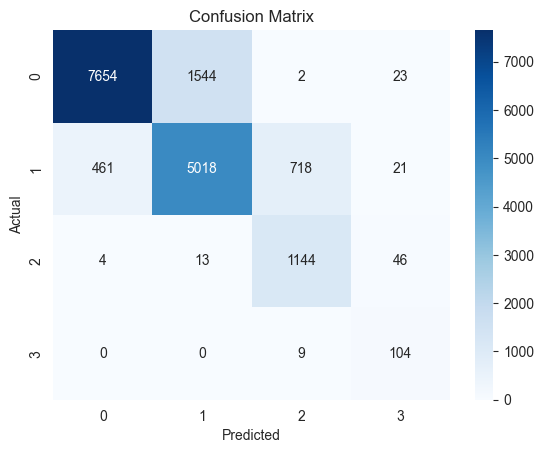

In [12]:
#Avaliação da rede para classificação
clf_trainer.evaluate(X_clf_test_t, y_clf_test_t)
y_pred_clf = clf_trainer.predict(X_clf_test_t)
print("Predicted classes:", torch.unique(y_pred_clf, return_counts=True))
print("Actual classes:", torch.unique(y_clf_test_t))

cm = confusion_matrix(y_clf_test_t.numpy(), y_pred_clf.numpy())
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
#Regressão com Neural Network
X_reg_train = analizer_reg.data_train
y_reg_train = analizer_reg.labels_train

# Convert to tensors with proper shapes
X_reg_train_t = torch.tensor(X_reg_train.values, dtype=torch.float32)
y_reg_train_t = torch.tensor(y_reg_train.values, dtype=torch.float32).reshape(-1, 1)

X_reg_test_t = torch.tensor(analizer_reg.data_test.values, dtype=torch.float32)
y_reg_test_t = torch.tensor(analizer_reg.labels_test.values, dtype=torch.float32).reshape(-1, 1)

# Model
reg_model = BaseNeuralNetwork(input_dim=X_reg_train_t.shape[1], output_dim=1, task_type='regression')
reg_trainer = NeuralNetworkTrainer(reg_model, task='regression')  # No class weights for regression
# Train
reg_trainer.train(X_reg_train_t, y_reg_train_t, epochs=100)

# Evaluation
with torch.no_grad():
    predictions = reg_model(X_reg_test_t)

    # No need to squeeze since both are now [batch_size, 1]
    mse = torch.mean((predictions - y_reg_test_t) ** 2).item()
    mae = torch.mean(torch.abs(predictions - y_reg_test_t)).item()

    # Calculate R² score
    y_mean = torch.mean(y_reg_test_t)
    ss_tot = torch.sum((y_reg_test_t - y_mean) ** 2)
    ss_res = torch.sum((y_reg_test_t - predictions) ** 2)
    r2 = 1 - (ss_res / ss_tot)

    print(f"Mean Squared Error: {mse:.4f}")
    print(f"Mean Absolute Error: {mae:.4f}")
    print(f"R² Score: {r2:.4f}")

    # Optional: Plot some predictions vs actual
    print("\nSample predictions vs actual values:")
    for i in range(min(10, len(predictions))):
        print(f"Sample {i}: Actual = {y_reg_test_t[i].item():.4f}, Predicted = {predictions[i].item():.4f}")


torch.save(reg_model.state_dict(), model_output_dir+"NeuralNetworkRegressor.pth")
print(f"Model state dictionary saved to {model_output_dir}/NeuralNetworkRegressor.pth")

Epoch 0 - Loss: 10.7162
Epoch 10 - Loss: 7.2931
Epoch 20 - Loss: 18.2231
Epoch 30 - Loss: 32.8914
Epoch 40 - Loss: 11.8047
Epoch 50 - Loss: 79.4230
Epoch 60 - Loss: 9.0305
Epoch 70 - Loss: 9.5308
Epoch 80 - Loss: 3.8785
Epoch 90 - Loss: 11.2926
Mean Squared Error: 178.2608
Mean Absolute Error: 3.1967
R² Score: -0.0426

Sample predictions vs actual values:
Sample 0: Actual = 29.5000, Predicted = 29.0954
Sample 1: Actual = 14.5000, Predicted = 14.2497
Sample 2: Actual = 6.5000, Predicted = 4.3330
Sample 3: Actual = 13.5000, Predicted = 13.4497
Sample 4: Actual = 9.5000, Predicted = 8.4785
Sample 5: Actual = 7.0000, Predicted = 3.8191
Sample 6: Actual = 6.0000, Predicted = 8.4750
Sample 7: Actual = 8.0000, Predicted = 8.6381
Sample 8: Actual = 19.0000, Predicted = 15.0602
Sample 9: Actual = 7.0000, Predicted = 6.0385


# K-Prototypes (Clustering por partição)

Índices categóricos identificados para K-Prototypes: [14, 15, 16, 17, 18]

Avaliando K-Prototypes com n_clusters = 3...
Parâmetros: n_clusters=3
Custo (Distorção): 1018403.0395
 -> Novo melhor conjunto de parâmetros para K-Prototypes encontrado: {'n_clusters': 3} (Custo=1018403.0395)

Avaliando K-Prototypes com n_clusters = 4...
Parâmetros: n_clusters=4
Custo (Distorção): 945615.7474
 -> Novo melhor conjunto de parâmetros para K-Prototypes encontrado: {'n_clusters': 4} (Custo=945615.7474)

Avaliando K-Prototypes com n_clusters = 5...
Parâmetros: n_clusters=5
Custo (Distorção): 887272.5856
 -> Novo melhor conjunto de parâmetros para K-Prototypes encontrado: {'n_clusters': 5} (Custo=887272.5856)
------------------------------
Melhores parâmetros encontrados para K-Prototypes: {'n_clusters': 5}
Melhor Custo: 887272.5856
Re-treinando o modelo K-Prototypes com 5 clusters no conjunto de treino completo...
Saving model in ../out/models/KPrototypesClustering_nClusters.pkl
Melhor modelo K-Proto

C:\Users\usoda\Github Projects\DataScience\code\model_building\KPrototypes.py:167: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data=X_df, ax=axes[i], palette='viridis')
C:\Users\usoda\Github Projects\DataScience\code\model_building\KPrototypes.py:167: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data=X_df, ax=axes[i], palette='viridis')
C:\Users\usoda\Github Projects\DataScience\code\model_building\KPrototypes.py:167: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=feature, data

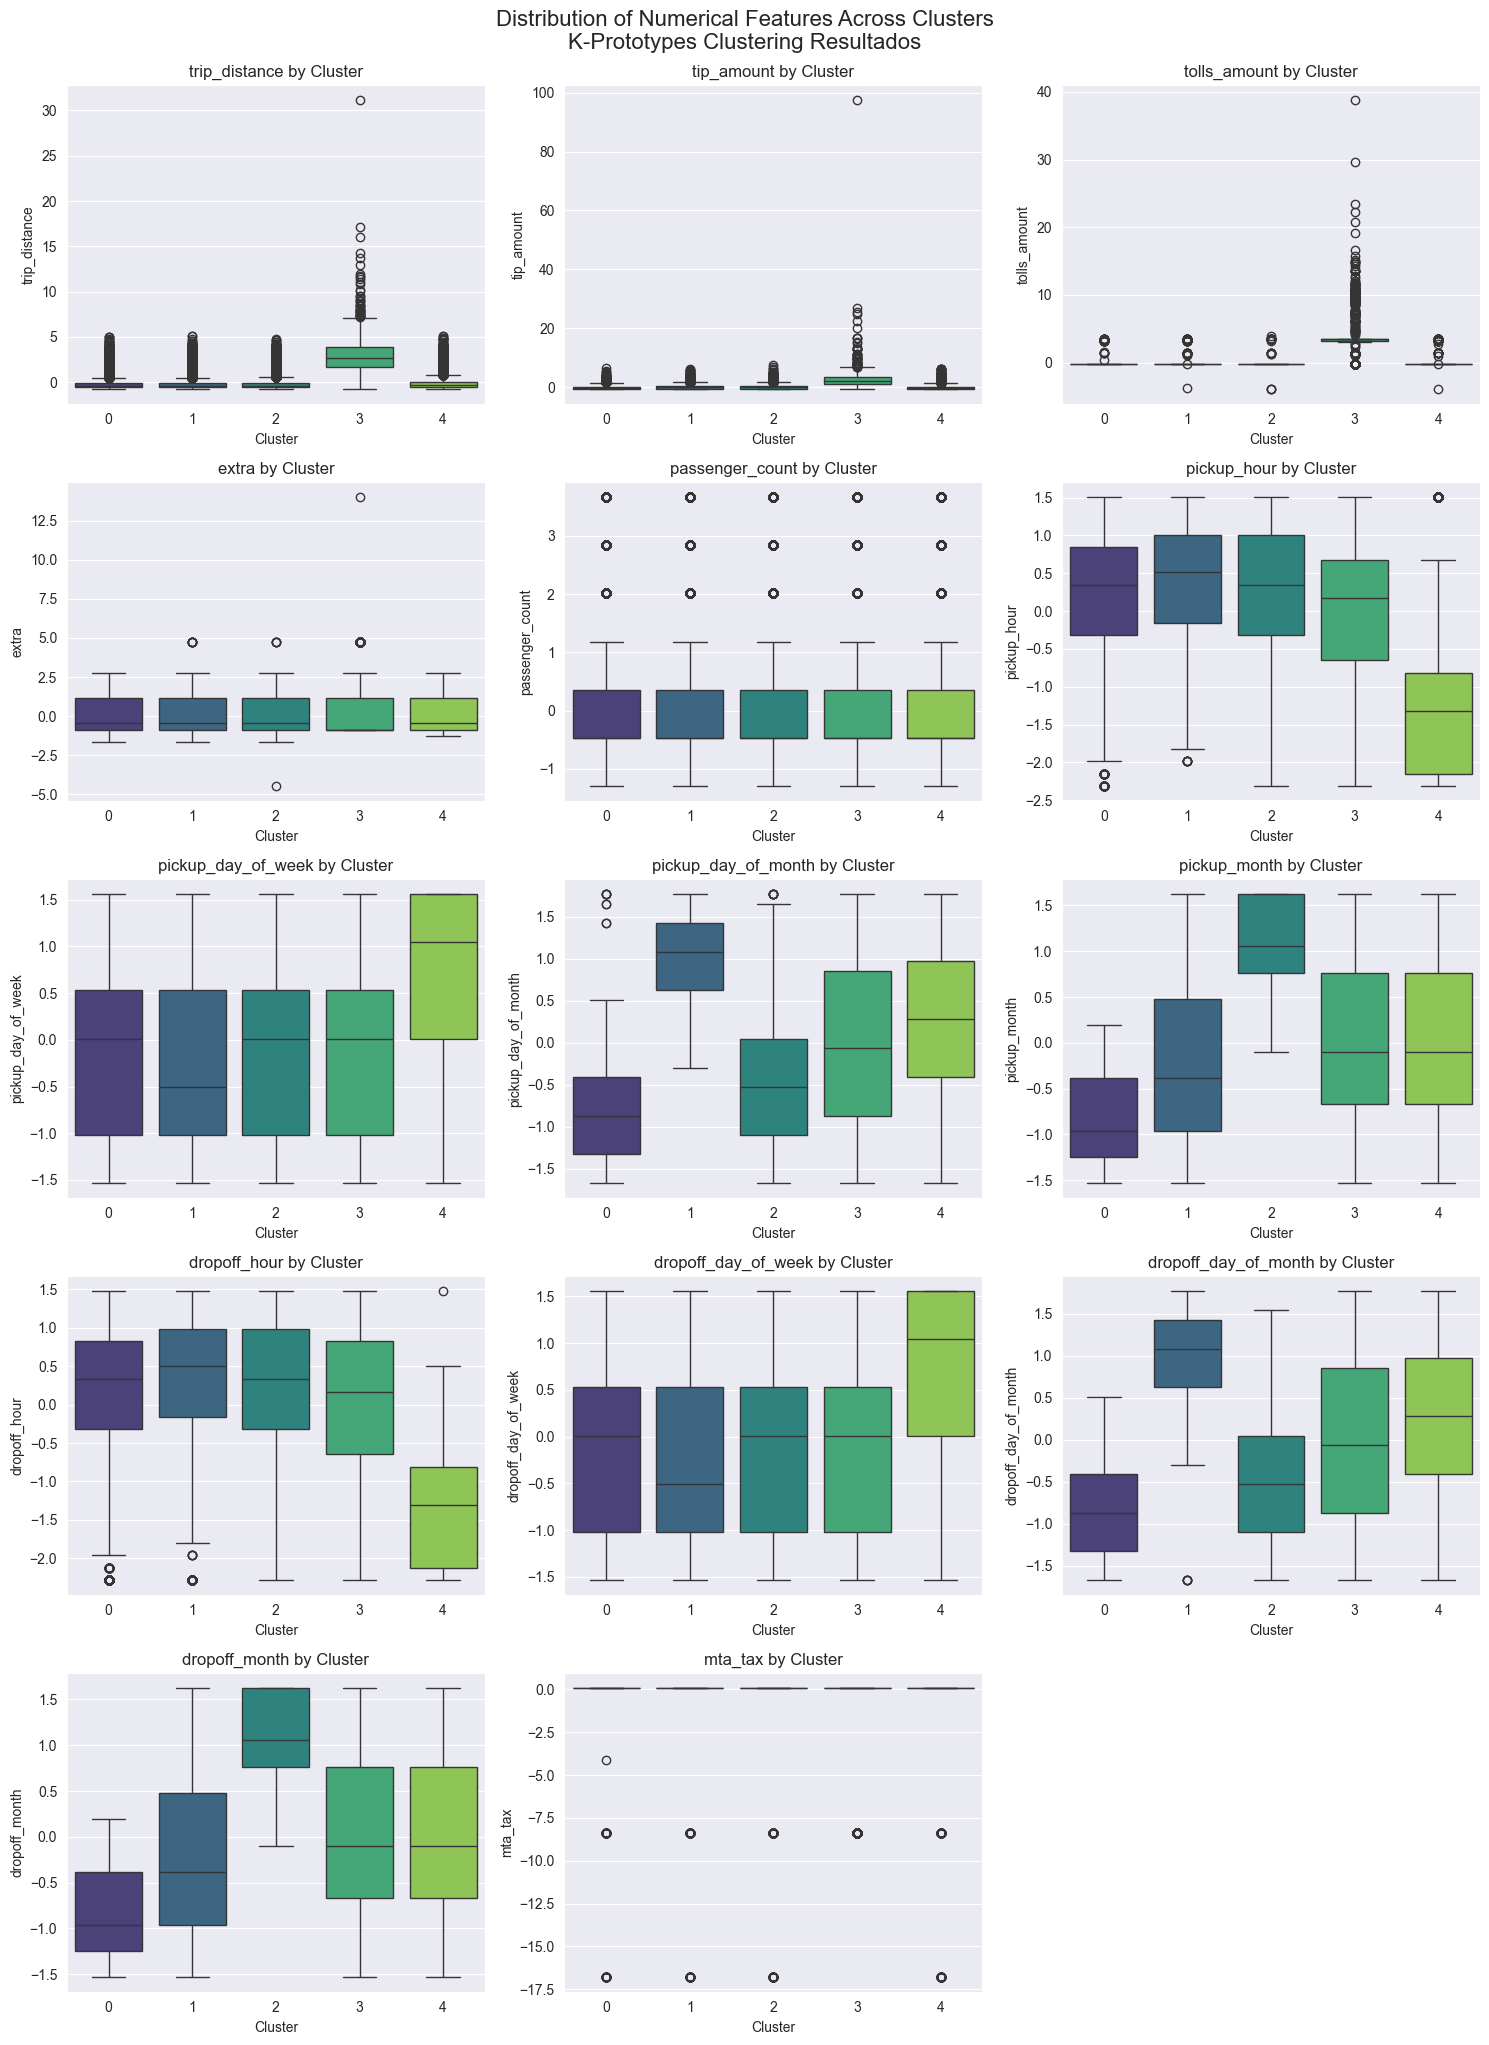


--- Pair Plot of First 2 Numerical Features (if applicable) ---


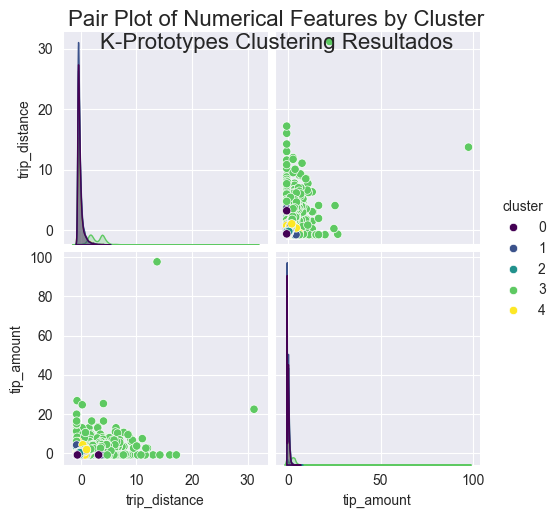


--- Visualizing Categorical Features for K-Prototypes Clustering Resultados ---


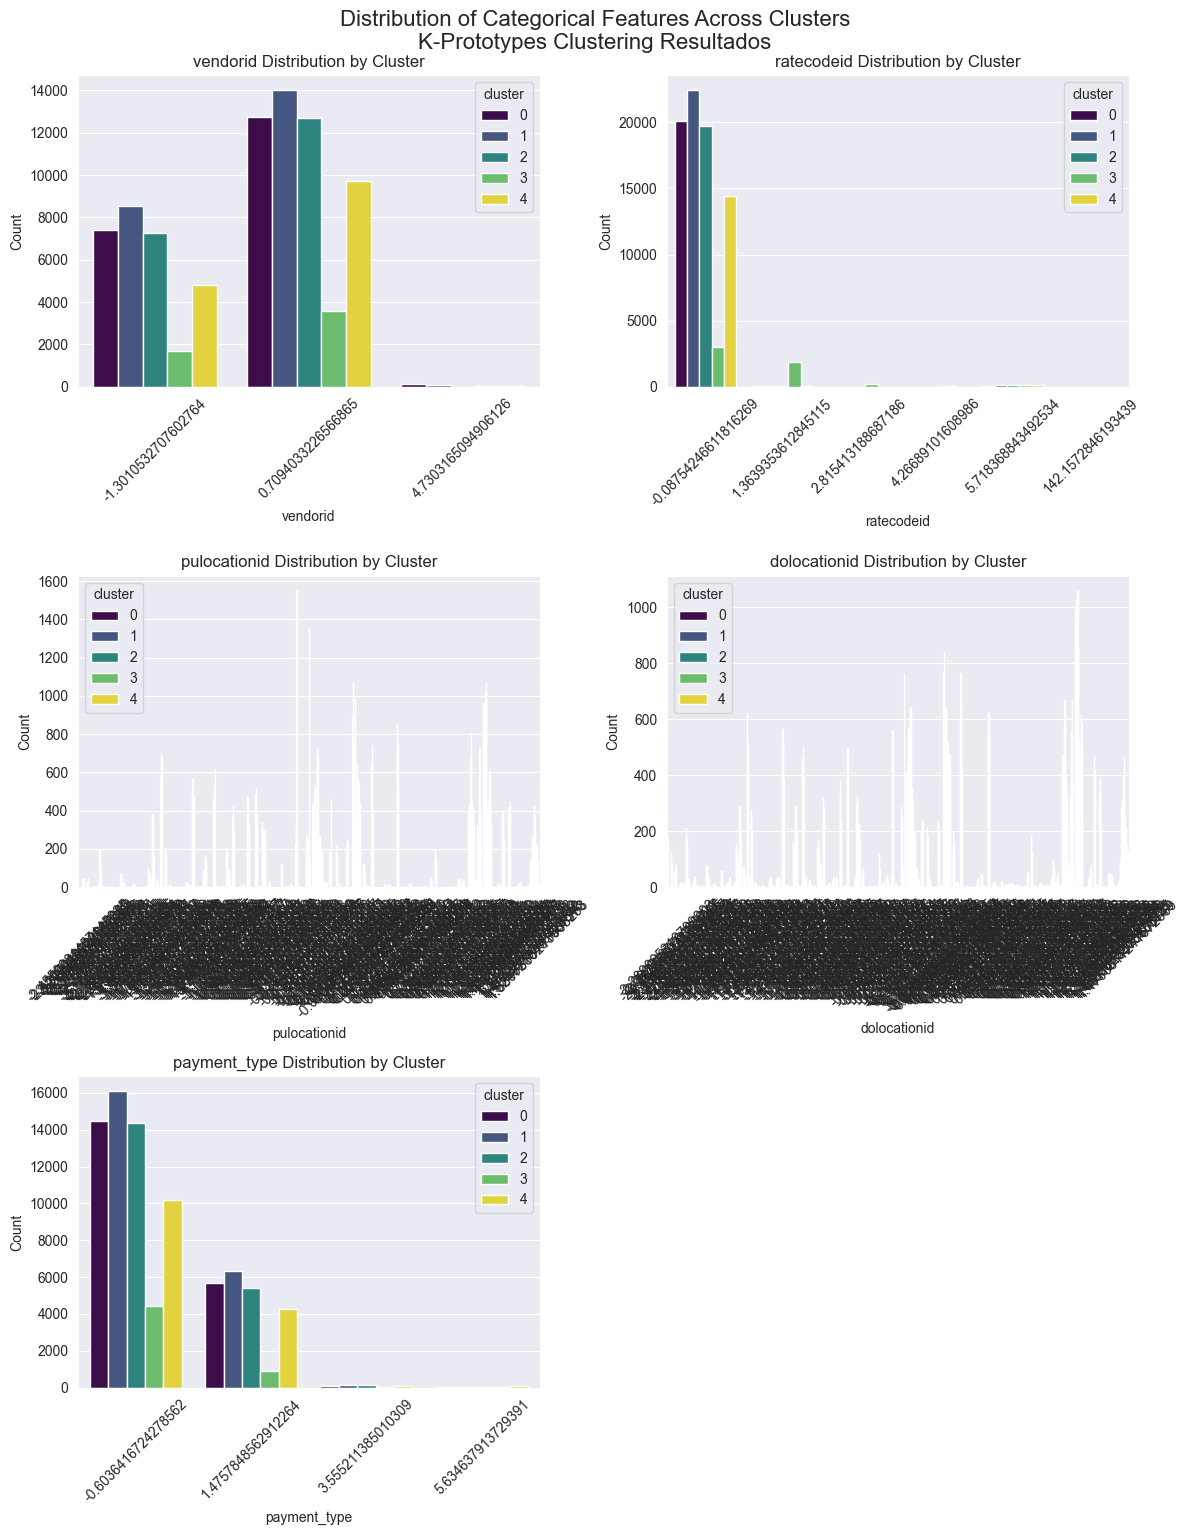


--- Cluster Centroids ---

Numerical Centroids:
Ocorreu um erro inesperado durante a plotagem dos clusters: Shape of passed values is (19, 1), indices imply (5, 14)

Script execution finished.


In [4]:
categorical_column_names_for_kproto = [
    'vendorid',
    'ratecodeid',
    'pulocationid',
    'dolocationid',
    'payment_type'
]

categorical_indices_kproto = []
if hasattr(analizer_reg, 'data_train') and isinstance(analizer_reg.data_train, pd.DataFrame):
    # Get the indices of the specified categorical column names
    for col_name in categorical_column_names_for_kproto:
        if col_name in analizer_reg.data_train.columns:
            categorical_indices_kproto.append(analizer_reg.data_train.columns.get_loc(col_name))
        else:
            print(f"Warning: Column '{col_name}' specified as categorical not found in data_train.")

    if not categorical_indices_kproto:
        print("\nCRITICAL ERROR: Categorical column indices for K-Prototypes NOT defined.")
        print("The manually specified columns were not found or are invalid.")
        print("Please ensure 'categorical_column_names_for_kproto' contains the correct names of your categorical features.")
        print("Cannot proceed with K-Prototypes without this information.")
else:
    print("Error: 'analizer_reg' or 'data_train' not found or is not a Pandas DataFrame. Please ensure 'analizer_reg' is initialized.")
    print("\nCRITICAL ERROR: Categorical column indices for K-Prototypes NOT defined.")
    print("Cannot proceed with K-Prototypes without this information.")
    categorical_indices_kproto = [] # Ensure it's empty if data is not available


if categorical_indices_kproto: # Only proceed if indices are found
    print(f"Categorical indices identified for K-Prototypes: {categorical_indices_kproto}")

    # Values for n_clusters. Can be adjusted based on data exploration.
    n_clusters_values_kproto = [3, 4, 5] # Example values for number of clusters
    best_cost_kproto = float('inf')
    best_params_kproto = None
    all_kproto_results = {} # Stores all results

    for n_cl in n_clusters_values_kproto:
        current_params = {'n_clusters': n_cl}
        print(f"\nEvaluating K-Prototypes with n_clusters = {n_cl}...")

        try:
            # Instantiate KPrototypes model
            # random_state is important for reproducibility of initialization
            kproto_model = KPrototypesModel(
                n_clusters=n_cl,
                categorical_indices=categorical_indices_kproto,
                n_init=10, # Run 10 times with different seeds and take the best result
                random_state=42
            )

            # Fit the model on the training data
            # For clustering, 'y' is ignored in the fit function
            kproto_model.fit(analizer_reg.data_train)

            # Evaluate the model (get the cost)
            results_kproto = kproto_model.evaluate()
            all_kproto_results[n_cl] = results_kproto

            current_cost = results_kproto.get('cost')
            print(f"Parameters: n_clusters={n_cl}")
            if current_cost is not None:
                print(f"Cost (Distortion): {current_cost:.4f}")

                # Logic to select the best model based on the lowest cost
                if current_cost < best_cost_kproto:
                    best_cost_kproto = current_cost
                    best_params_kproto = current_params
                    print(f" -> New best parameter set for K-Prototypes found: {best_params_kproto} (Cost={best_cost_kproto:.4f})")

        except Exception as e:
            print(f"An error occurred during K-Prototypes evaluation for n_clusters {n_cl}: {e}")

    # --- Train and Save the Best K-Prototypes Clustering Model ---
    if best_params_kproto is not None:
        print("-" * 30)
        print(f"Best parameters found for K-Prototypes: {best_params_kproto}")
        print(f"Best Cost: {best_cost_kproto:.4f}")

        # 1. Re-train the final model with the best parameters on ALL training data
        print(f"Re-training the K-Prototypes model with {best_params_kproto['n_clusters']} clusters on the complete training set...")
        final_best_kproto_model = KPrototypesModel(
            n_clusters=best_params_kproto['n_clusters'],
            categorical_indices=categorical_indices_kproto,
            n_init=10, # Keep the n_init used in selection
            random_state=42
        )
        final_best_kproto_model.fit(analizer_reg.data_train)

        # 2. Save the best K-Prototypes CLUSTERING model
        model_filename_kproto = f"KPrototypesClustering_nClusters.pkl"
        model_full_path_kproto = model_output_dir + model_filename_kproto

        # Assuming the KPrototypes class inherits from BaseModel and has a serialize method
        final_best_kproto_model.serialize(str(model_full_path_kproto)) # Serialize expects string or PathLike
        print(f"Best K-Prototypes model saved successfully!")
        print("-" * 30)

        # 3. Plot the clustering results
        print("\n" + "=" * 40)
        print("--- Visualizing K-Prototypes Clusters ---")
        try:
            final_best_kproto_model.plot_clusters(analizer_reg.data_train, title="K-Prototypes Clustering Results")
            print("K-Prototypes cluster visualization completed.")
        except RuntimeError as e:
            print(f"Could not plot clusters. Error: {e}")
        except Exception as e:
            print(f"An unexpected error occurred during cluster plotting: {e}")

    else:
        print("-" * 30)
        print("No K-Prototypes model was successfully evaluated and selected.")
        print("-" * 30)

print("\nScript execution finished.")

# HDBSCAN

In [ ]:
print("\n" + "=" * 40)
print("--- Clustering with HDBSCANMixed ---")

# Example values for HDBSCAN hyperparameters
hdbscan_min_cluster_sizes = [50, 100, 200]
hdbscan_min_samples_values = [None, 5, 10]

best_model_hdbscan = None
best_score = -1.0 # Will store the best Adjusted Rand Score or similar
best_hdbscan_params = None
best_noise_percentage_hdbscan = float('inf') # For heuristics without ground truth
all_hdbscan_results = {}

y_test_for_eval = getattr(analizer_reg, 'labels_train', None)

for min_cluster_s in hdbscan_min_cluster_sizes:
    for min_s_val in hdbscan_min_samples_values:
        current_params = {'min_cluster_size': min_cluster_s, 'min_samples': min_s_val}
        print(f"\nEvaluating HDBSCANMixed with min_cluster_size = {min_cluster_s}, min_samples = {min_s_val}...")

        try:
            hdbscan_model = HDBSCANMixed(
                min_cluster_size=min_cluster_s,
                min_samples=min_s_val,
                metric='euclidean',
                prediction_data=True
            )

            hdbscan_model.fit(analizer_reg.data_train)

            results_hdbscan = hdbscan_model.evaluate(y_test=y_test_for_eval)
            all_hdbscan_results[(min_cluster_s, min_s_val)] = results_hdbscan

            print(f"Parameters: min_cluster_size={min_cluster_s}, min_samples={min_s_val}")

            unique_labels = np.unique(hdbscan_model.labels)
            num_clusters = len(unique_labels[unique_labels != -1])
            noise_points = np.sum(hdbscan_model.labels == -1)
            total_points = len(hdbscan_model.labels)
            noise_percentage = (noise_points / total_points) * 100 if total_points > 0 else 0

            print(f"Number of Clusters Found: {num_clusters}")
            print(f"Number of Noise Points: {noise_points} ({noise_percentage:.2f}%)")

            current_ari = results_hdbscan.get('adjusted_rand_score', -1.0)
            current_nmi = results_hdbscan.get('normalized_mutual_info_score', -1.0)

            if 'adjusted_rand_score' in results_hdbscan:
                print(f"Adjusted Rand Score: {current_ari:.4f}")
            if 'normalized_mutual_info_score' in results_hdbscan:
                print(f"Normalized Mutual Information Score: {current_nmi:.4f}")

            if y_test_for_eval is not None:
                if current_ari > best_score:
                    best_score = current_ari
                    best_hdbscan_params = current_params
                    best_model_hdbscan = hdbscan_model
                    print(f" -> New best HDBSCANMixed parameters found (based on ARI): {best_hdbscan_params} (ARI={best_score:.4f})")
            else:
                if num_clusters > 1 and noise_percentage < best_noise_percentage_hdbscan:
                    best_noise_percentage_hdbscan = noise_percentage
                    best_hdbscan_params = current_params
                    best_model_hdbscan = hdbscan_model
                    print(f" -> New best HDBSCANMixed parameters found (heuristic): {best_hdbscan_params} (Noise={best_noise_percentage_hdbscan:.2f}%, Clusters={num_clusters})")

        except Exception as e:
            print(f"An error occurred during HDBSCANMixed evaluation for parameters {current_params}: {e}")

# ========================================
# 6. SAVING AND VISUALIZING BEST MODEL
# ========================================
if best_hdbscan_params is not None:
    print("-" * 30)
    print(f"Best parameters found for HDBSCANMixed after evaluation: {best_hdbscan_params}")
    if y_test_for_eval is not None:
        print(f"Best Adjusted Rand Score: {best_score:.4f}")
    else:
        print(f"Lowest Noise Percentage (Heuristic): {best_noise_percentage_hdbscan:.2f}%")

    print(f"Saving the best HDBSCANMixed model...")

    min_cs = best_hdbscan_params['min_cluster_size']
    min_s = best_hdbscan_params['min_samples'] if best_hdbscan_params['min_samples'] is not None else 'None'

    try:
        best_model_hdbscan.serialize(model_output_dir + "HDCSCAN_Clustering.pkl")
        print(f"Best HDBSCANMixed model saved successfully!")
    except Exception as e:
        print(f"Error saving the HDBSCANMixed model: {e}")

    print("-" * 30)

    print("\n" + "=" * 40)
    print("--- Visualizing HDBSCANMixed Clusters ---")
    try:
        best_model_hdbscan.plot_clusters(analizer_reg.data_train, title="HDBSCANMixed Clustering Results")
        print("HDBSCANMixed cluster visualization completed.")
    except RuntimeError as e:
        print(f"Could not plot clusters. Error: {e}")
    except Exception as e:
        print(f"An unexpected error occurred during cluster plotting: {e}")

else:
    print("-" * 30)
    print("No HDBSCANMixed model was successfully evaluated and selected.")
    print("-" * 30)

print("\nScript execution finished.")


--- Clustering with HDBSCANMixed ---

Evaluating HDBSCANMixed with min_cluster_size = 50, min_samples = None...
Iniciando o pré-processamento e treinamento HDBSCAN...


C:\Users\usoda\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\usoda\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
